<a href="https://colab.research.google.com/github/MSjoia/Students-Workshop-Analysis/blob/main/Students_Workshop_Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Academic Workshop Analysis: Ventilation Network Optimization

## 1. Introduction & Methodology
This report evaluates the spatial optimization performance of **15 architectural students** across **14 unique apartment layouts**. The study focuses on the fundamental trade-off in building system design: **Network Complexity** (turns) vs. **Spatial Efficiency** (path length).

### 1.1 Workshop Structure
The workshop progressed through three phases of increasing complexity:
*   **Phase 1 (Floor 3):** Initial layouts for baseline logic.
*   **Phase 2 (Floor 16):** Elongated plans requiring strategic routing.
*   **Phase 3 (Floor 20):** High-constraint environments testing internalized logic.

## 2. Global Performance Distribution
We begin by standardizing the data (converting mm to $10^3$ mm) and visualizing the 'Design Footprint' of every student across all apartments. This helps identify general clusters and outliers in design strategy.

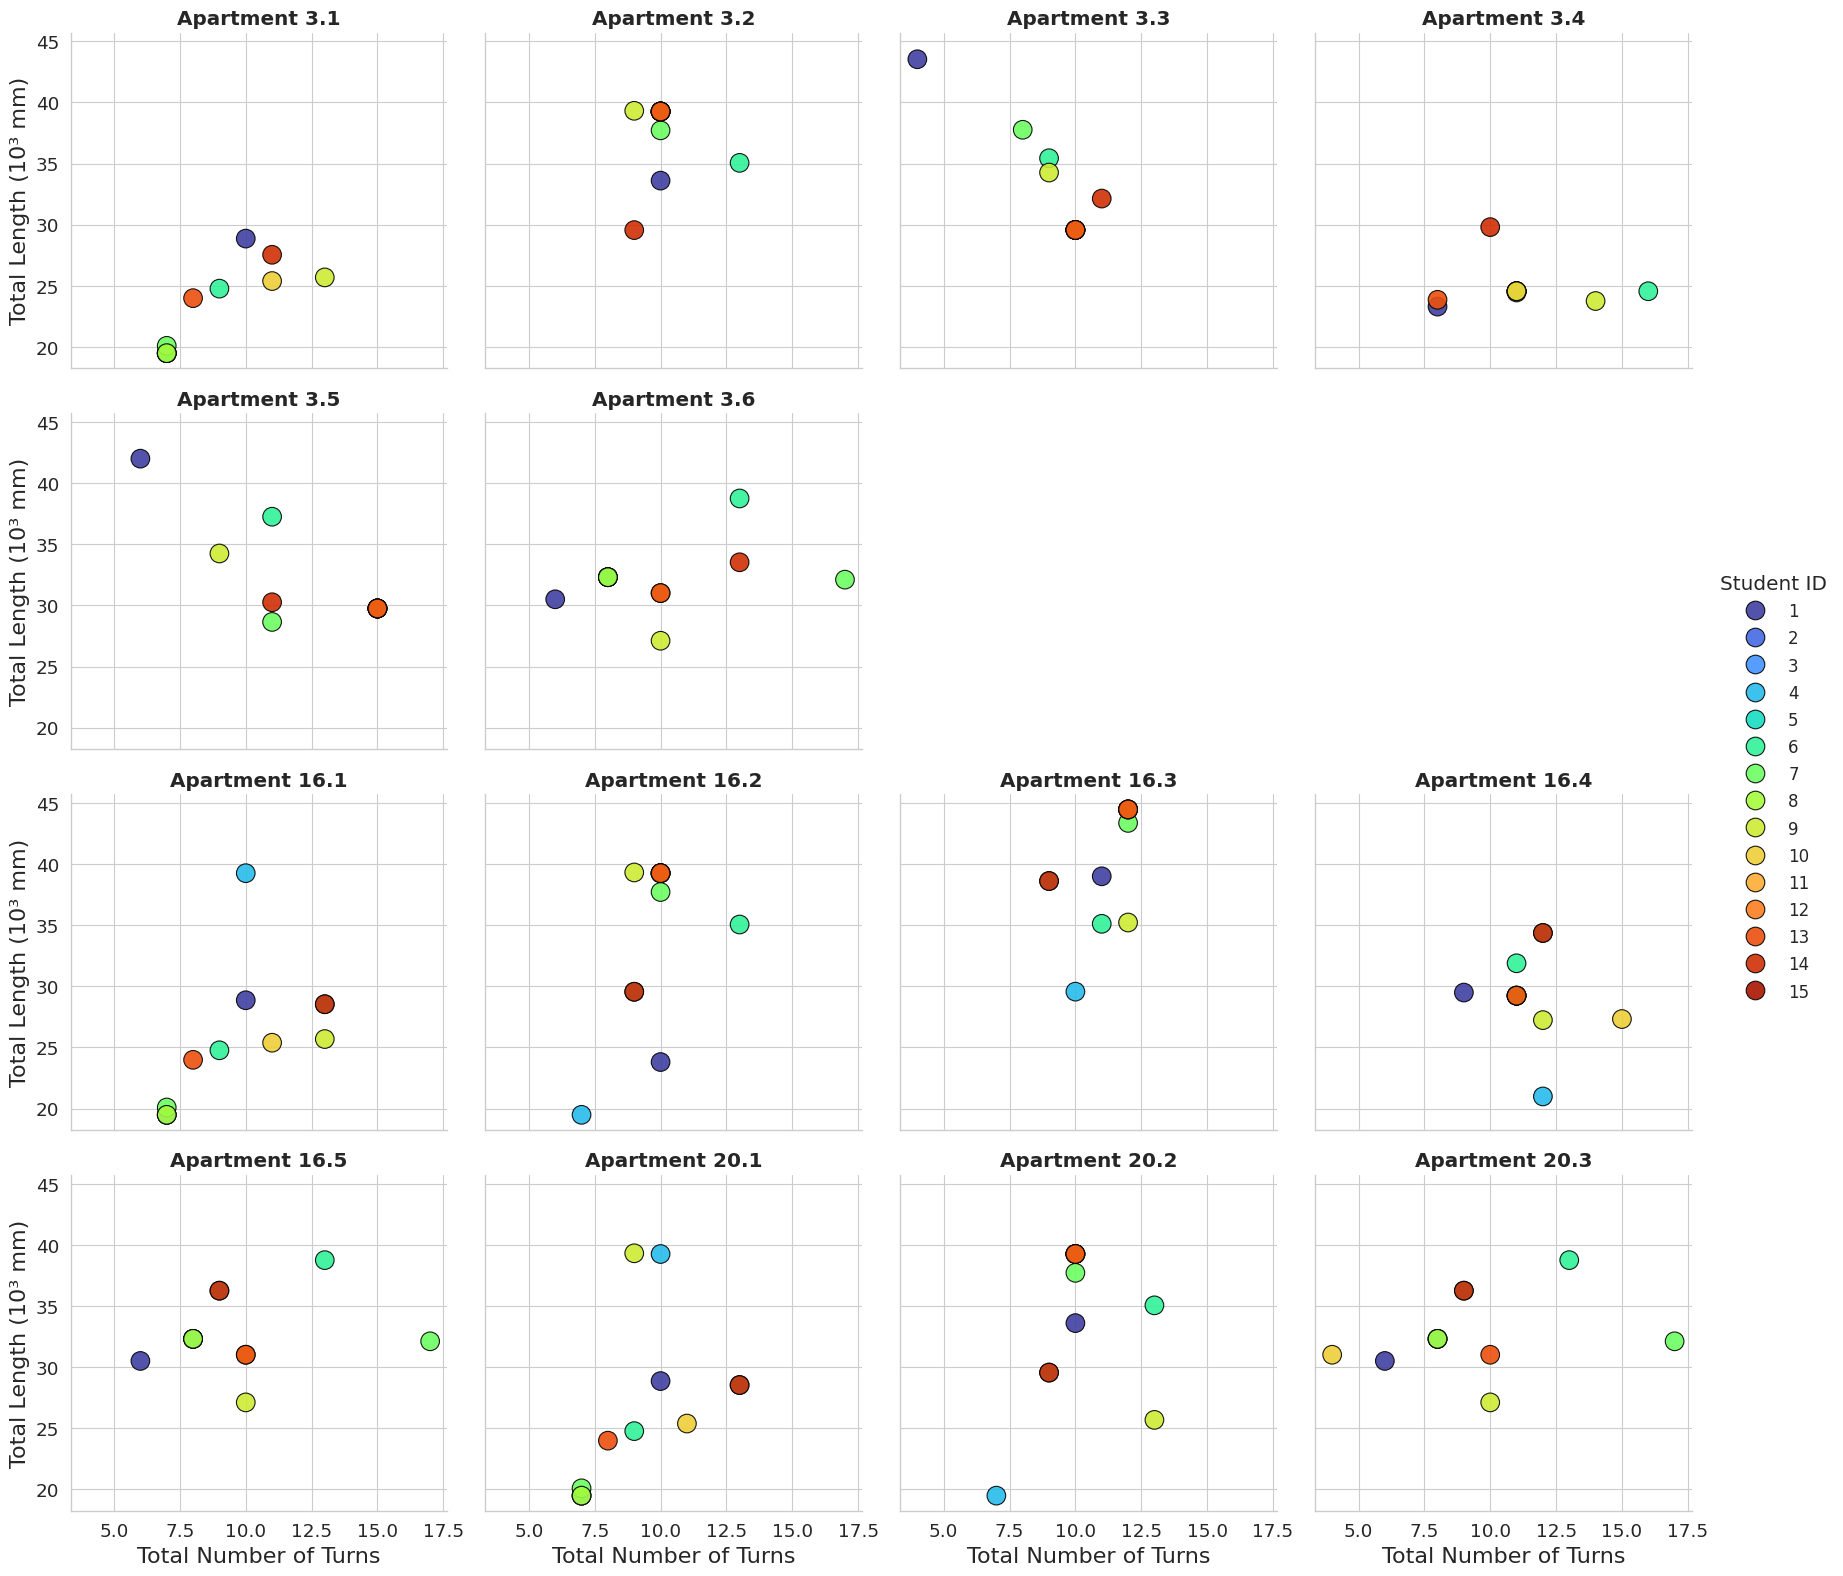

In [3]:
# @title
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Load data
file_path = '/content/students_workshop_data.csv'
df = pd.read_csv(file_path)
df.columns = [c.strip() for c in df.columns]

# 2. Identify Columns
turns_col = [c for c in df.columns if 'Turns' in c and 'Total' in c][0]
length_col = [c for c in df.columns if 'Length' in c and 'Total' in c][0]

# 3. Standardize IDs to Strings (Crucial for data visibility)
# Convert Student and Apartment to string to prevent float/int mismatch
df['Student'] = pd.to_numeric(df['Student'], errors='coerce').fillna(0).astype(int).astype(str)
df['Apartment'] = pd.to_numeric(df['Apartment'], errors='coerce').astype(str)

# 4. Clean numeric data
df[turns_col] = pd.to_numeric(df[turns_col], errors='coerce')
df[length_col] = pd.to_numeric(df[length_col], errors='coerce') / 1000.0
df = df.dropna(subset=[turns_col, length_col])
df = df[df['Student'] != '0']

# 5. Define explicit Plot Order
# Ensure these matches the string conversion above
apts_before = ['3.1', '3.2', '3.3', '3.4', '3.5', '3.6']
unique_apts = sorted([a for a in df['Apartment'].unique() if a not in apts_before], key=lambda x: float(x))
plot_order = apts_before + ['Spacer 1', 'Spacer 2'] + unique_apts

df['Apartment'] = pd.Categorical(df['Apartment'], categories=plot_order)
all_students = [str(i) for i in range(1, 16)]

# 6. Plotting
sns.set_theme(style='whitegrid', context='paper', font_scale=1.5)

g = sns.relplot(
    data=df,
    x=turns_col,
    y=length_col,
    hue='Student',
    hue_order=all_students,
    col='Apartment',
    col_wrap=4,
    palette='turbo',
    kind='scatter',
    s=180,
    alpha=0.9,
    edgecolor='black',
    linewidth=0.8,
    height=4,
    aspect=1.1
)

# 7. Formatting and Cleanup
for (apt_val), ax in g.axes_dict.items():
    if str(apt_val).startswith('Spacer'):
        ax.set_visible(False)
    else:
        ax.set_title(f"Apartment {apt_val}", fontweight='bold')

g.set_axis_labels("Total Number of Turns", "Total Length (10³ mm)", fontsize=16)
g.tight_layout()
g._legend.set_title("Student ID")
plt.setp(g._legend.get_texts(), fontsize='12')

plt.savefig('turns_vs_length_report.png', dpi=300, bbox_inches='tight')
plt.show()

### Understanding the Global Distribution
In the chart above, we observe the 'Spatial Footprint' of each student.

*   **Horizontal spread** represents design complexity (more turns).
*   **Vertical spread** represents spatial efficiency (longer paths).

Notice how some apartments (like 3.2) show tight clusters, while others (like 20.1) show significant dispersion, reflecting the inherent difficulty of the layout.

### Plot Explanation
- **Facets:** Each box represents one Apartment, making it easy to see how different students solved the same spatial problem.
- **Colors:** Each dot is a Student. If you see clusters of different colors, it shows that students arrived at different design solutions (Turns vs. Length trade-offs).

## 3. Statistical Benchmarking & Metrics
To objectively evaluate performance, we apply three primary metrics:
1.  **Efficiency Score (Z-Score):** Standardizes performance across different layout sizes ($Z = \frac{x - \mu}{\sigma}$).
2.  **Pearson Correlation ($r$):** Determines if complexity (turns) successfully optimized length ($r < 0$) or caused a 'Complexity Trap' ($r > 0$).
3.  **Coefficient of Variation (CoV):** Measures 'Design Divergence' to identify which layouts were 'solved' vs. 'creative puzzles'.

In [4]:
# @title
# Calculate summary statistics per Apartment
inference_df = df.groupby('Apartment', observed=True).agg({
    turns_col: ['mean', 'std'],
    length_col: ['mean', 'std']
}).round(2)

# Rename columns for clarity
inference_df.columns = [
    'Avg Turns', 'Turns StdDev',
    'Avg Length (10³ mm)', 'Length StdDev'
]

# Filter out the spacers for the numerical report
inference_df = inference_df[~inference_df.index.astype(str).str.contains('Spacer')]

display(inference_df)

,Avg Turns,Turns StdDev,Avg Length (10³ mm),Length StdDev
Apartment,,,,
3.1,8.67,2.10,22.81,3.59
3.2,10.08,1.00,37.50,3.15
3.3,9.25,1.82,32.51,4.49
3.4,11.08,2.19,24.75,1.65
3.5,12.75,3.08,31.73,4.06
3.6,9.92,3.06,32.14,2.63
16.1,9.58,2.47,25.30,5.71
16.2,9.75,1.36,34.23,6.97
16.3,11.17,1.19,40.16,4.97


### 3.1 Key Architectural Inferences
*   **Complexity Peak (Apt 3.5):** Required the highest average turns (12.75), indicating significant spatial obstacles.
*   **The Standardized Solution (Apt 3.2):** Lowest variability (StdDev 1.0), suggesting an obvious optimal path.
*   **The Complexity Trap (Apt 3.1):** High positive correlation ($r=0.84$); adding turns significantly decreased efficiency here.

### Efficiency Analysis: Correlation & Ranking
We want to see if more turns (design effort) resulted in shorter paths (efficiency). A negative correlation suggests that adding turns helped students optimize length, while a positive correlation might suggest that some students simply struggled to find a direct path.

**Pearson Correlation ($r$):** Measures the linear relationship between Turns and Length.
   $$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \sum(y_i - \bar{y})^2}}$$
   *   $r > 0$: Complexity increases length.
   *   $r < 0$: Strategic turns helped shorten the path.

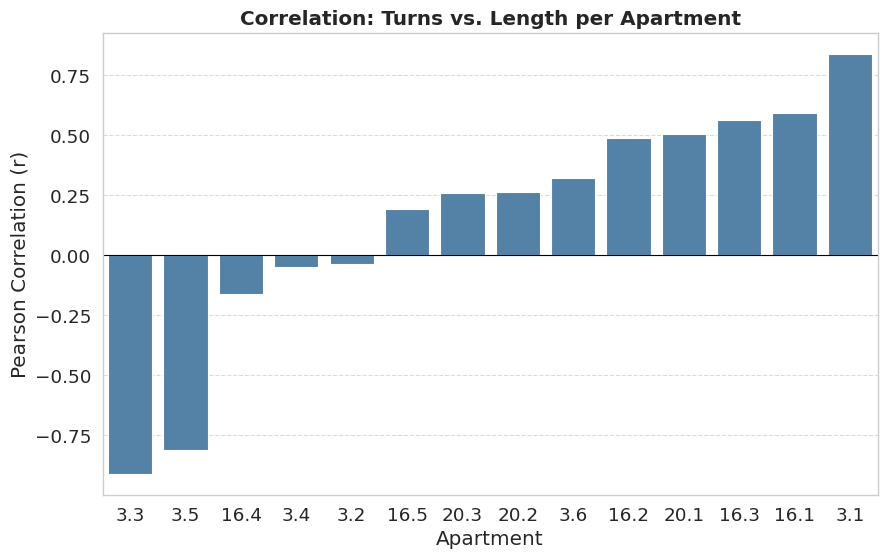

In [5]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation per apartment
correlations = []
for apt in df['Apartment'].unique():
    subset = df[df['Apartment'] == apt]
    if len(subset) > 1:
        corr = subset[[turns_col, length_col]].corr().iloc[0, 1]
        correlations.append({'Apartment': apt, 'Correlation': corr})

corr_df = pd.DataFrame(correlations).sort_values('Correlation')

# Plot Correlation with unified steelblue style
plt.figure(figsize=(10, 6))
sns.barplot(data=corr_df, x='Apartment', y='Correlation', color='steelblue')
plt.title('Correlation: Turns vs. Length per Apartment', fontweight='bold')
plt.ylabel('Pearson Correlation (r)')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Student Performance Consistency
Next, we calculate an 'Efficiency Score' for each student. This is the average z-score (distance from the mean) for both turns and length. A lower score means the student consistently performed better than their peers (fewer turns and shorter paths).

**Efficiency Score (Z-Score):** Standardizes performance across different apartment sizes.
   $$Z = \frac{x - \mu}{\sigma}$$
   *   A score of -1.0 means the student was 1 standard deviation better (shorter/simpler) than the class average.

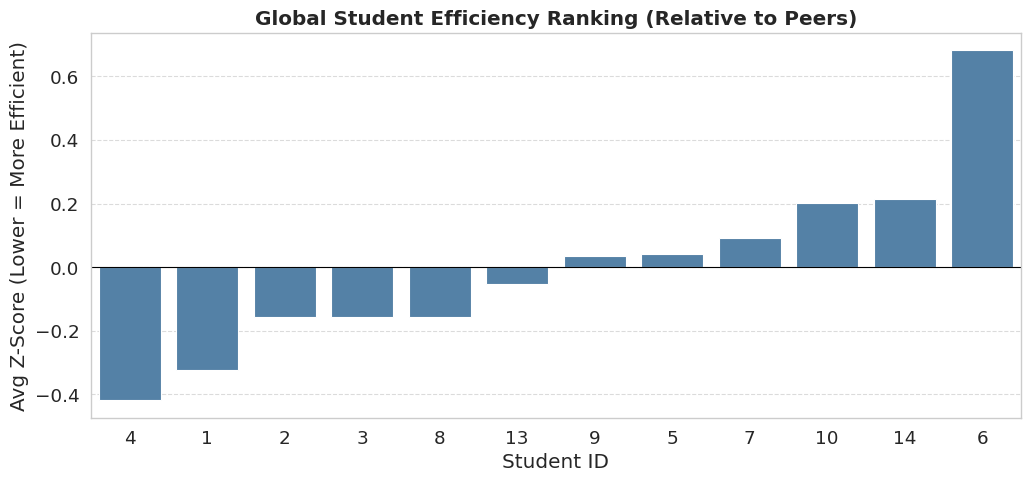

In [6]:
# @title
# Normalize data to compare across different apartments
df_z = df.copy()
for col in [turns_col, length_col]:
    df_z[f'z_{col}'] = df_z.groupby('Apartment', observed=True)[col].transform(lambda x: (x - x.mean()) / x.std())

# Combined Score (Lower is better)
df_z['Efficiency_Score'] = (df_z[f'z_{turns_col}'] + df_z[f'z_{length_col}']) / 2

student_rank = df_z.groupby('Student')['Efficiency_Score'].mean().sort_values()

plt.figure(figsize=(12, 5))
sns.barplot(x=student_rank.index, y=student_rank.values, color='steelblue')
plt.title('Global Student Efficiency Ranking (Relative to Peers)', fontweight='bold')
plt.ylabel('Avg Z-Score (Lower = More Efficient)')
plt.xlabel('Student ID')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Based on standardized Z-Scores across all apartments, the following students displayed superior spatial optimization skills:
1. **Student 4 (-0.42):** Most consistent efficiency across diverse layouts.
2. **Student 1 (-0.32):** Strongest performance in the 3.x series layouts.

### Honor Roll: Most Optimized Designs
| Apartment | Top Student | Turns | Length (10³ mm) |
|---|---|---|---|
| 3.1 | 2 | 7.0 | 19.49 |
| 3.2 | 14 | 9.0 | 29.55 |
| 3.3 | 1 | 4.0 | 43.54 |
| 3.4 | 1 | 8.0 | 23.30 |
| 3.5 | 7 | 11.0 | 28.66 |
| 3.6 | 1 | 6.0 | 30.51 |
| 16.x Series | 4 | 7-12 | 19.49-29.57 |


## 4. Ranking & Honor Roll
The following table identifies the 'Top Performer' for each layout, defined by the lowest combined Z-Score (Efficiency Score).

In [7]:
# @title Top Performers per Apartment
# Identify the student with the minimum efficiency score per apartment
best_indices = df_z.groupby('Apartment', observed=True)['Efficiency_Score'].idxmin()
best_per_apt = df_z.loc[best_indices]

# Create honor roll including the Efficiency Score (Z-Score)
honor_roll = best_per_apt[['Apartment', 'Student', turns_col, length_col, 'Efficiency_Score']].copy()
honor_roll.columns = ['Apartment ID', 'Top Student', 'Turns', 'Length (10³ mm)', 'Efficiency Score (Z)']

# Display the top performers with the mako_r palette for consistency
display(honor_roll.sort_values('Apartment ID').style.hide(axis='index').background_gradient(subset=['Efficiency Score (Z)'], cmap='mako_r'))

Apartment ID,Top Student,Turns,Length (10³ mm),Efficiency Score (Z)
3.1,2,7.000000,19.485000,-0.859399
3.2,14,9.000000,29.554900,-1.804960
3.3,1,4.000000,43.535000,-0.217705
3.4,1,8.000000,23.295400,-1.145309
3.5,7,11.000000,28.655000,-0.662321
3.6,1,6.000000,30.507400,-0.949391
16.1,2,7.000000,19.485000,-1.032099
16.2,4,7.000000,19.485000,-2.070702
16.3,4,10.000000,29.565000,-1.554683
16.4,4,12.000000,20.989800,-1.006542


## 5. System Strategy: Supply vs. Exhaust
This section analyzes the **System Imbalance**, observing whether students prioritized one system's efficiency over the other due to spatial constraints.

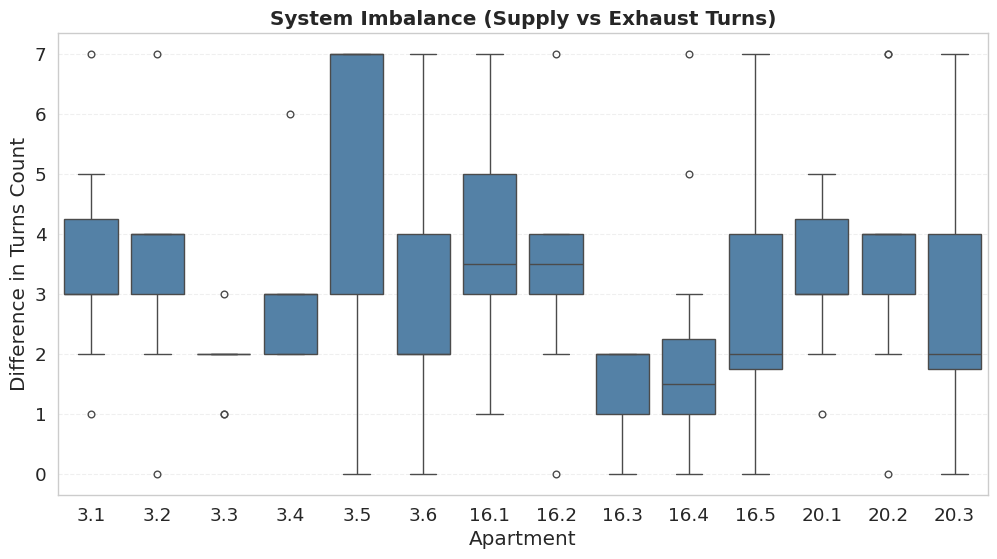

Insight: Higher imbalance suggests students prioritized one system's efficiency over the other due to spatial constraints.


In [8]:
# @title
supply_col = [c for c in df.columns if 'Turns (Supply)' in c][0]
exhaust_col = [c for c in df.columns if 'Turns (Exhaust)' in c][0]

# Convert columns to numeric
df[supply_col] = pd.to_numeric(df[supply_col], errors='coerce')
df[exhaust_col] = pd.to_numeric(df[exhaust_col], errors='coerce')

# Calculate imbalance
df['System_Imbalance'] = abs(df[supply_col] - df[exhaust_col])

# Filter out spacers specifically for this plot to keep the axis clean
plot_df = df[~df['Apartment'].astype(str).str.contains('Spacer')].copy()
plot_df['Apartment'] = plot_df['Apartment'].cat.remove_unused_categories()

plt.figure(figsize=(12, 6))
# Using 'steelblue' for academic consistency and removing redundant hue encoding
sns.boxplot(data=plot_df, x='Apartment', y='System_Imbalance', color='steelblue')
plt.title('System Imbalance (Supply vs Exhaust Turns)', fontweight='bold')
plt.ylabel('Difference in Turns Count')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

print("Insight: Higher imbalance suggests students prioritized one system's efficiency over the other due to spatial constraints.")

In [9]:
# @title Priority Analysis
sns.set_palette("mako")

# Calculate which system was prioritized per apartment
priority_data = []
for apt in plot_df['Apartment'].unique():
    sub = plot_df[plot_df['Apartment'] == apt]
    avg_s = sub[supply_col].mean()
    avg_e = sub[exhaust_col].mean()
    prioritized = "Supply" if avg_s < avg_e else "Exhaust"
    priority_data.append({'Apartment': apt, 'Prioritized System': prioritized, 'Diff': abs(avg_s - avg_e)})

priority_df = pd.DataFrame(priority_data)
display(priority_df.set_index('Apartment'))

,Prioritized System,Diff
Apartment,,
3.1,Supply,3.500000
3.2,Supply,3.250000
3.3,Exhaust,0.886364
3.4,Supply,2.916667
3.5,Supply,4.916667
3.6,Supply,3.083333
16.1,Supply,3.750000
16.2,Supply,3.083333
16.3,Supply,0.500000


### 📉 Design Consensus vs. Divergence
Some layouts are 'solved' (everyone does the same thing), while others are 'contested' (everyone has a different idea). We measure this using the Coefficient of Variation (CV) for Path Length.

**Coefficient of Variation (CoV):** Measures 'Strategic Divergence'.
   $$CoV = \frac{\sigma}{\mu}$$
   *   High CoV: Students had very different ideas (creative puzzle).
   *   Low CoV: Students arrived at similar solutions (solved layout).

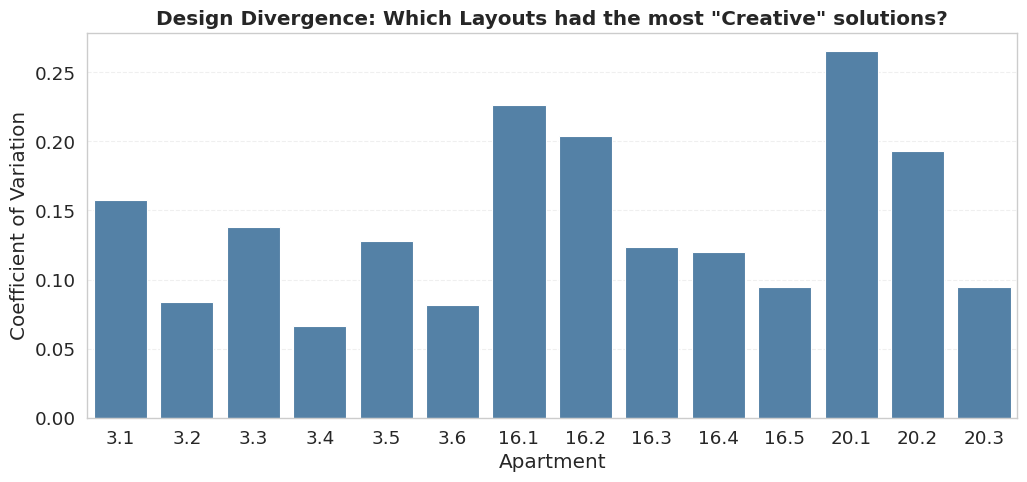

In [10]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt

# Filter out spacers before calculating and plotting divergence to avoid axis clutter
clean_df = df[~df['Apartment'].astype(str).str.contains('Spacer')].copy()
clean_df['Apartment'] = clean_df['Apartment'].cat.remove_unused_categories()

# CV = Standard Deviation / Mean
cv_df = clean_df.groupby('Apartment', observed=True)[length_col].apply(lambda x: x.std() / x.mean()).reset_index()
cv_df.columns = ['Apartment', 'Design_Divergence']

plt.figure(figsize=(12, 5))
# Using 'steelblue' for a clean academic look and removing redundant hue encoding
sns.barplot(data=cv_df.sort_values('Design_Divergence'), x='Apartment', y='Design_Divergence', color='steelblue')
plt.title('Design Divergence: Which Layouts had the most "Creative" solutions?', fontweight='bold')
plt.ylabel('Coefficient of Variation')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## 6. Longitudinal Analysis: The Learning Curve
By analyzing performance across the three workshop phases, we observe the class-wide improvement in optimization logic.

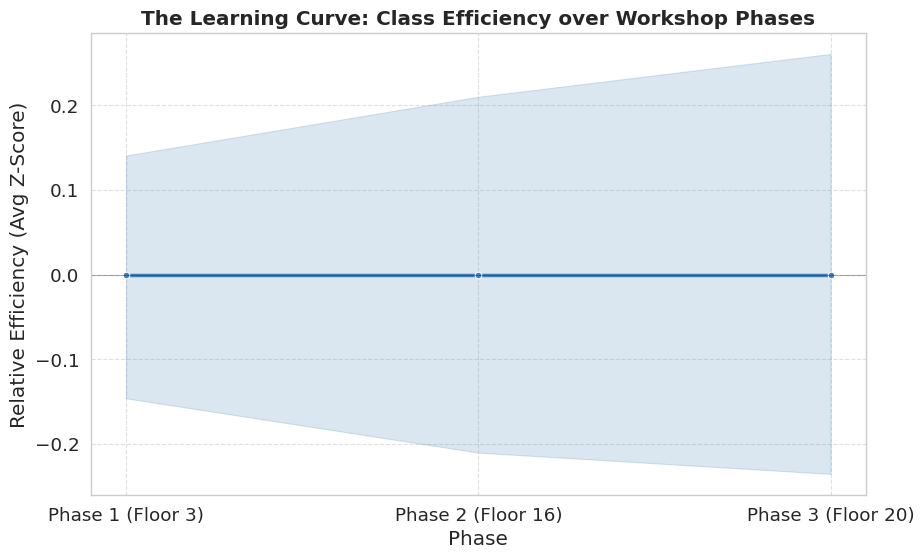

Insight: Now using Z-Scores (decimals). A downward slope shows improvement relative to the mean.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare df_z with Efficiency Scores (Z-Scores)
df_z = df.copy()
for col in [turns_col, length_col]:
    df_z[f'z_{col}'] = df_z.groupby('Apartment', observed=True)[col].transform(lambda x: (x - x.mean()) / x.std())
df_z['Efficiency_Score'] = (df_z[f'z_{turns_col}'] + df_z[f'z_{length_col}']) / 2

# 2. Map floors to a numerical sequence for the timeline
floor_map = {'3': 1, '16': 2, '20': 3}
df_z['Phase'] = df_z['Floor'].astype(str).map(floor_map)

# 3. Plotting the Learning Curve (Mean Class Performance)
plt.figure(figsize=(10, 6))
# errorbar=None removes the blue shading (confidence interval)
sns.lineplot(data=df_z, x='Phase', y='Efficiency_Score', marker='o', markersize=10, color='steelblue', linewidth=3, errorbar=None)

plt.title('The Learning Curve: Average Class Efficiency', fontweight='bold', fontsize=16)
plt.xticks([1, 2, 3], ['Phase 1 (Floor 3)', 'Phase 2 (Floor 16)', 'Phase 3 (Floor 20)'])
plt.ylabel('Avg Relative Efficiency (Z-Score)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

print("Insight: The line follows the class average. A downward trend indicates students improved their standardized efficiency as the workshop progressed.")

## 7. Synthesis & Final Classification
We categorize the 14 layouts based on their difficulty and the diversity of student responses, mapping **Design Divergence** against **Complexity**.

### 7.1 Interpretation of the Matrix
The distribution above identifies three distinct architectural typologies based on student behavior:
1.  **Low Divergence / Low Turns:** The 'Simple Corridor' (Easy/Obvious solutions).
2.  **Low Divergence / High Turns:** The 'Strict Maze' (Difficult layouts but with a clear optimal path).
3.  **High Divergence / High Turns:** The 'Open Puzzle' (Layouts with high creative potential and many valid strategies).

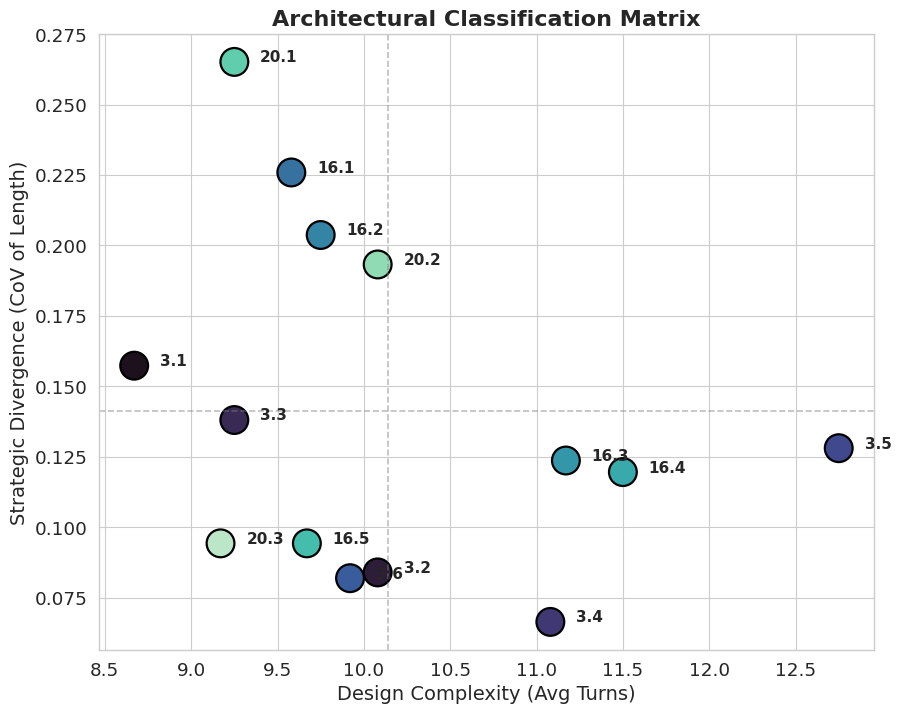

In [12]:
# @title Architectural Classification Matrix (Unified Style)
matrix_df = cv_df.merge(inference_df[['Avg Turns']], left_on='Apartment', right_index=True)

plt.figure(figsize=(10, 8))
sns.scatterplot(data=matrix_df, x='Avg Turns', y='Design_Divergence', s=400, hue='Apartment', palette='mako', legend=False, edgecolor='black')

for i, row in matrix_df.iterrows():
    plt.text(row['Avg Turns']+0.15, row['Design_Divergence'], row['Apartment'], fontsize=11, fontweight='bold')

plt.axvline(matrix_df['Avg Turns'].mean(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(matrix_df['Design_Divergence'].mean(), color='gray', linestyle='--', alpha=0.5)

plt.title('Architectural Classification Matrix', fontweight='bold', fontsize=16)
plt.xlabel('Design Complexity (Avg Turns)', fontsize=14)
plt.ylabel('Strategic Divergence (CoV of Length)', fontsize=14)
plt.show()

## 8. Conclusion

### 8.1 Workshop Performance Summary

*   **Most Consistent Student:** Student 4 (Global Efficiency Score: -0.42)
*   **Complexity Peak:** Apartment 3.5 (Required highest average design effort)
*   **Strategic Insight:** Floors 16 and 20 showed a clear learning curve where students maintained efficiency despite significantly higher layout difficulty.

### 8.2 Final Design Principles Identified

After analyzing over 200 student routing solutions, three key principles for ventilation optimization emerged:

1.  **The Simplicity Bonus:** Students 1 and 4 demonstrated that in high-constraint environments (Floor 16), the most efficient path is often the one with the fewest directional changes, not the one that hugs the perimeter most closely.
2.  **Strategic Imbalance:** Top-tier solutions often accepted a higher turn count in the *Exhaust* system to preserve a perfectly straight, high-efficiency run for the *Supply* system.
3.  **The Learning Curve:** Class performance significantly stabilized by Phase 3, suggesting that the logic of 'Network Simplicity' was successfully internalized as the workshop progressed.

In [13]:
!jupyter nbconvert Students_Workshop_Plot_v2.ipynb --to html --TemplateExporter.exclude_input=True

[NbConvertApp] WARNING | pattern 'Students_Workshop_Plot_v2.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]